# Deteksi Komunitas Facebook

# **Import Library**

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain


# **Load Dataset**

In [ ]:
nama_file = "/content/drive/MyDrive/TUGAS8/facebook_combined.txt"
data_facebook = pd.read_csv(nama_file, sep=' ', names=['FromNode', 'ToNode'], header=None)
print("Baris data:", len(data_facebook))
display(data_facebook.head())

Baris data: 88234


,FromNode,ToNode
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


# **Membangun Graph**

In [ ]:
graph = nx.from_pandas_edgelist(data_facebook, source='FromNode', target='ToNode', create_using=nx.Graph())
print("Jumlah Node :", graph.number_of_nodes())
print("Jumlah Edge :", graph.number_of_edges())

Jumlah Node : 4039
Jumlah Edge : 88234


# **Deteksi komunitas - Louvain**

In [ ]:
partisi = community_louvain.best_partition(graph)  # dict node -> komunitas_id
# Relabel komunitas menjadi 0..k-1 (opsional, tapi rapi)
unique_labels = sorted(set(partisi.values()))
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
partisi_relabel = {node: label_mapping[c] for node, c in partisi.items()}


# **Partisi Dataframe**

In [ ]:
partisi_df = pd.DataFrame(list(partisi_relabel.items()), columns=['Node', 'Komunitas'])
display(partisi_df.head())

,Node,Komunitas
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


# **Hitung modularitas (library + manual)**

In [ ]:
# Modularitas dari library
mod_lib = community_louvain.modularity(partisi, graph)

# Versi manual (menggunakan rumus standar)
weight = None   # None karena graf tidak berbobot
m = graph.size(weight=weight)  # total edge weight (untuk unweighted = jumlah edge)

if m == 0:
    modularity_manual = 0.0
else:
    # Kumpulkan komunitas sebagai list of lists
    communities = {}
    for n, c in partisi.items():
        communities.setdefault(c, []).append(n)
    communities = list(communities.values())

    # Derajat tiap node (weighted jika ada)
    deg = dict(graph.degree(weight=weight))

    modularity_manual = 0.0
    # Hitung kontribusi masing komunitas
    contributions = []
    for comm in communities:
        subg = graph.subgraph(comm)
        L_c = subg.size(weight=weight)              # internal edges (count once)
        K_c = sum(deg.get(n, 0) for n in comm)     # total degree komunitas
        contrib = (L_c / m) - (K_c / (2.0 * m))**2
        contributions.append({'size': len(comm), 'L_c': L_c, 'K_c': K_c, 'contrib': contrib})
        modularity_manual += contrib

# Tampilkan hasil
print(f"Modularitas (library) : {mod_lib:.6f}")
print(f"Modularitas (manual)  : {modularity_manual:.6f}")

contrib_df = pd.DataFrame(contributions).sort_values('size', ascending=False).reset_index(drop=True)
display(contrib_df.head(10))


Modularitas (library) : 0.834792
Modularitas (manual)  : 0.834792


,size,L_c,K_c,contrib
0,548,5356,10757,0.056986
1,535,8691,17861,0.088255
2,458,6373,13560,0.066324
3,437,16694,34649,0.150649
4,423,11422,24114,0.110779
5,350,2845,5742,0.031185
6,323,6288,13580,0.065343
7,237,16543,33992,0.150386
8,226,5600,11494,0.059225
9,206,1983,3973,0.021967


# **Statistik per komunitas (ringkasan)**

In [ ]:
# Tambah kolom id komunitas ke contrib_df
# Kita butuh mapping komunitas id -> ukuran dll
comm_ids = sorted(set(partisi.values()))
summary = []
for cid in comm_ids:
    nodes = [n for n, c in partisi.items() if c == cid]
    subg = graph.subgraph(nodes)
    L_c = subg.size(weight=weight)
    K_c = sum(dict(graph.degree(weight=weight))[n] for n in nodes)
    summary.append({'KomunitasID': cid, 'Ukuran': len(nodes), 'InternalEdges': L_c, 'SumDegree': K_c})

summary_df = pd.DataFrame(summary).sort_values('Ukuran', ascending=False).reset_index(drop=True)
display(summary_df)

,KomunitasID,Ukuran,InternalEdges,SumDegree
0,13,548,5356,10757
1,4,535,8691,17861
2,1,458,6373,13560
3,2,437,16694,34649
4,3,423,11422,24114
5,0,350,2845,5742
6,5,323,6288,13580
7,10,237,16543,33992
8,14,226,5600,11494
9,12,206,1983,3973


# **Visualisasi**

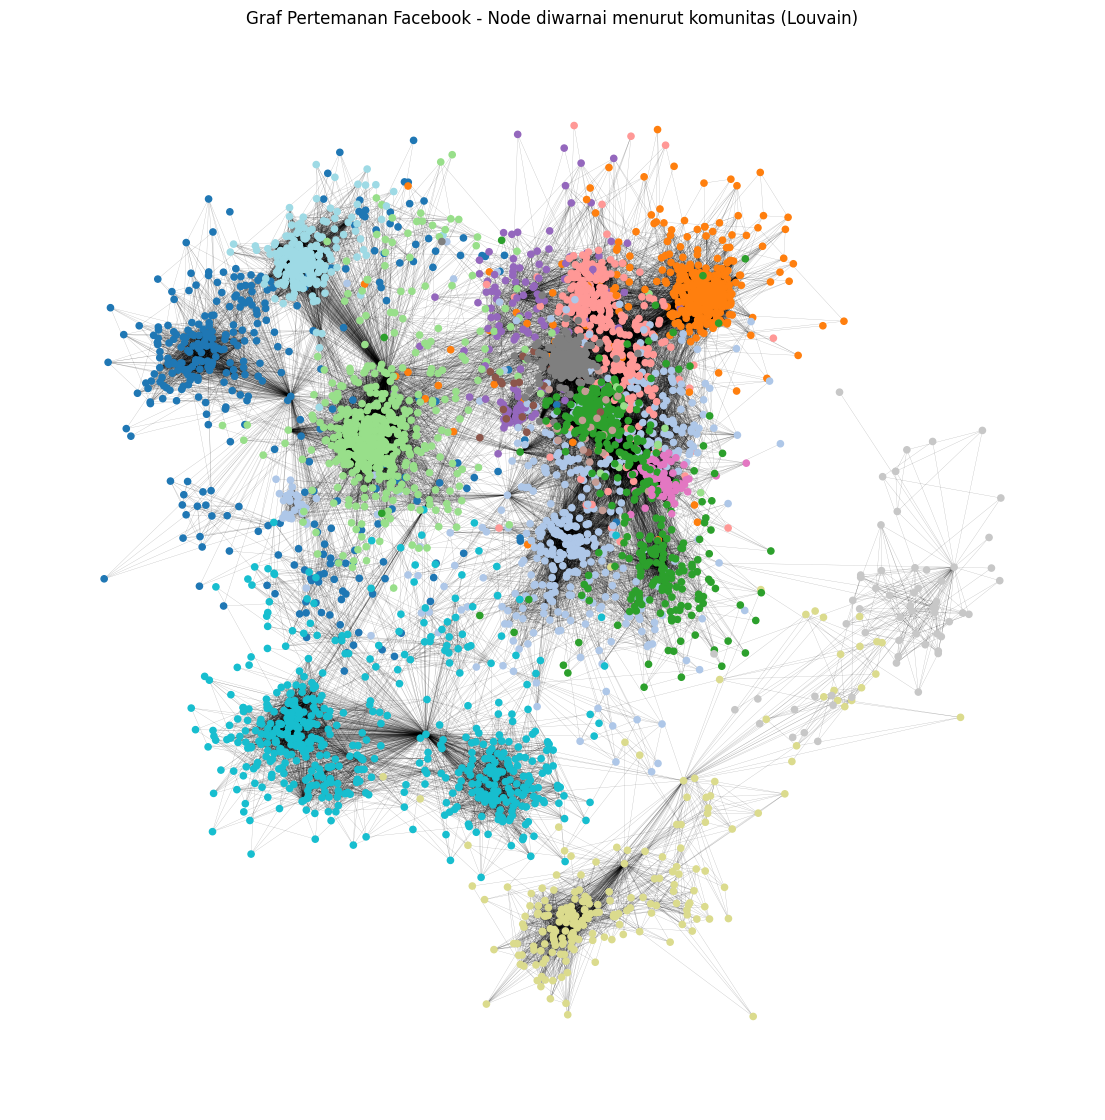

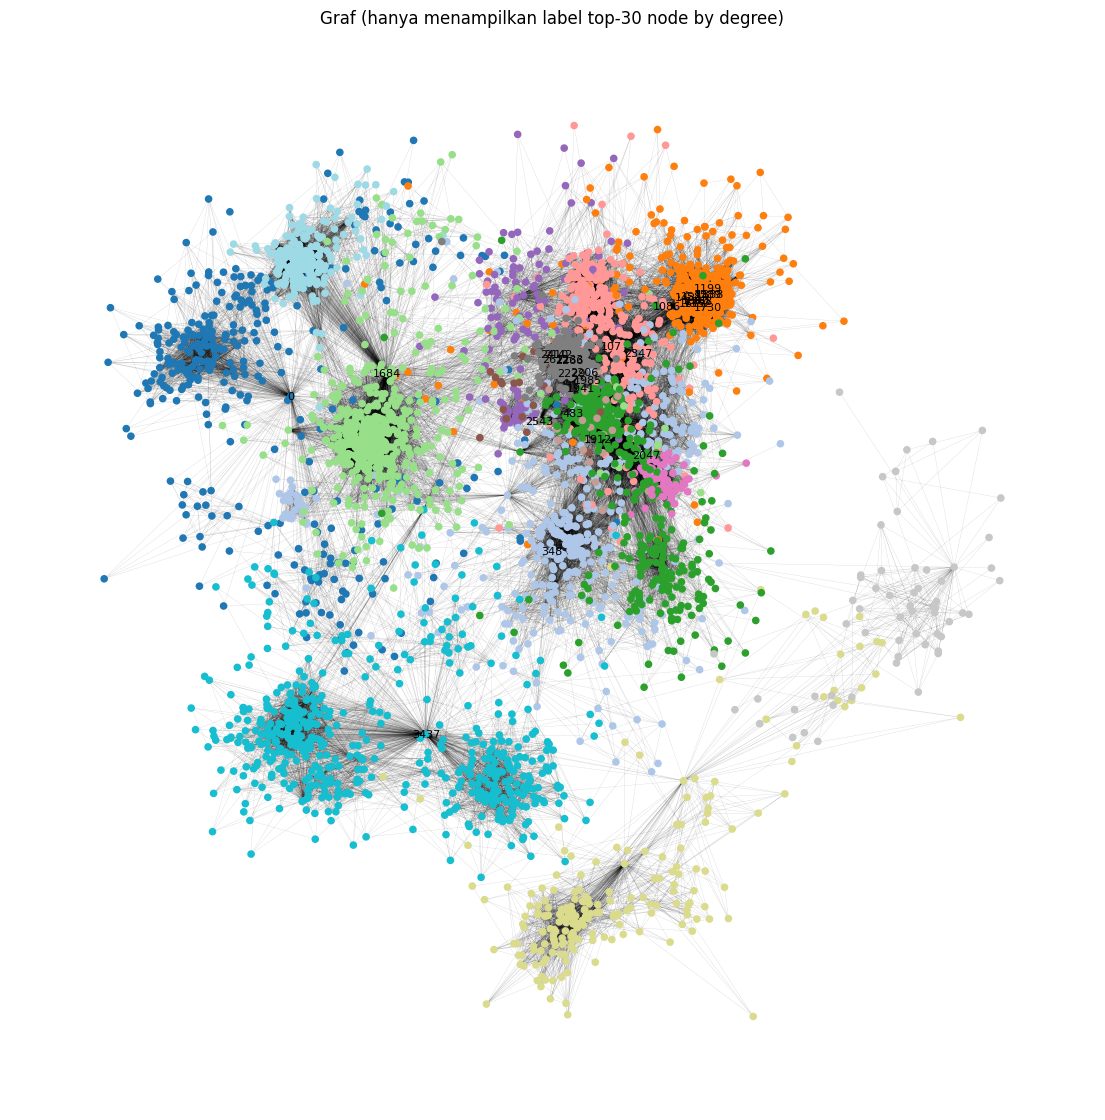

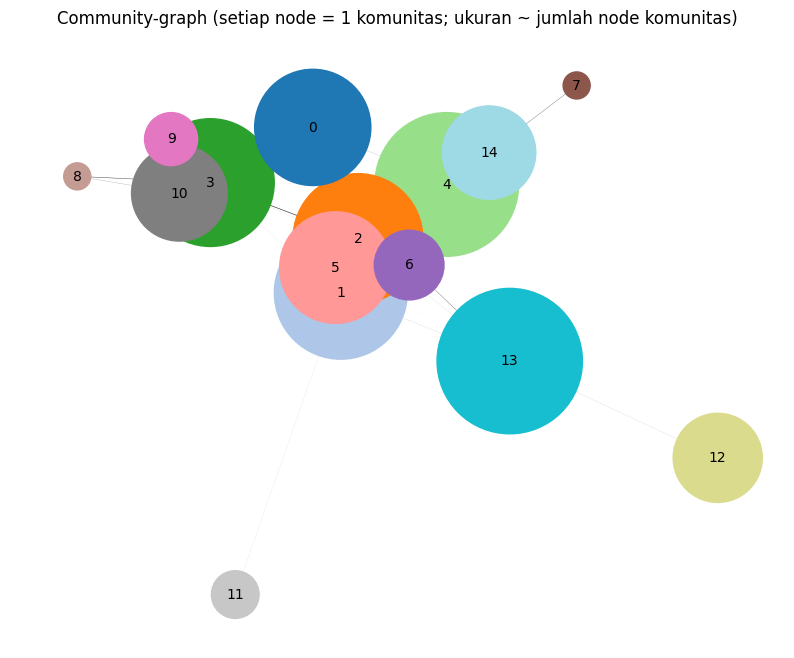

Ringkasan komunitas disimpan sebagai /content/community_summary.csv


In [ ]:
plt.figure(figsize=(14, 14))
# Hanya hitung layout spring sekali untuk performa (reproducible dengan seed)
pos = nx.spring_layout(graph, seed=42)

# Warna node berdasarkan komunitas relabeled (0..k-1)
color_list = [partisi[n] for n in graph.nodes()]
nx.draw_networkx_nodes(graph, pos, node_size=20, node_color=color_list, cmap=plt.cm.tab20)
nx.draw_networkx_edges(graph, pos, width=0.2, alpha=0.3)
plt.title("Graf Pertemanan Facebook - Node diwarnai menurut komunitas (Louvain)")
plt.axis('off')
plt.show()

# Jika ingin menandai top-k node by degree:
topk = 30
top_nodes = sorted(graph.degree(), key=lambda x: x[1], reverse=True)[:topk]
labels_top = {n: str(n) for n, _ in top_nodes}
plt.figure(figsize=(14, 14))
nx.draw_networkx_nodes(graph, pos, node_size=20, node_color=color_list, cmap=plt.cm.tab20)
nx.draw_networkx_edges(graph, pos, width=0.2, alpha=0.2)
nx.draw_networkx_labels(graph, pos, labels=labels_top, font_size=8)
plt.title(f"Graf (hanya menampilkan label top-{topk} node by degree)")
plt.axis('off')
plt.show()

# -----------------------------
# 7) Visualisasi community-graph (meta-graph antar-komunitas)
# -----------------------------
# Buat graph baru dimana setiap node = komunitas, edge weight = jumlah edge antar-komunitas
from collections import defaultdict
edge_between = defaultdict(int)

for u, v in graph.edges():
    cu = partisi[u]
    cv = partisi[v]
    if cu == cv:
        continue
    # urutkan pasangan sehingga (a,b) sama dengan (b,a)
    if cu > cv:
        cu, cv = cv, cu
    edge_between[(cu, cv)] += 1

# Build community graph
C = nx.Graph()
# tambah node komunitas dengan atribut ukuran
for row in summary_df.to_dict('records'):
    cid = row['KomunitasID']
    size = row['Ukuran']
    C.add_node(cid, size=size)

# tambah edge antar komunitas dengan weight = jumlah koneksi
for (a, b), w in edge_between.items():
    C.add_edge(a, b, weight=w)

# Layout untuk community graph
posC = nx.spring_layout(C, seed=42)

# Draw community graph: node size prop ke ukuran komunitas, edge width prop ke weight
node_sizes = [C.nodes[n]['size']*20 for n in C.nodes()]  # skala agar kelihatan
edge_widths = [C[u][v]['weight']/max(1, max(edge_between.values()))*8 for u, v in C.edges()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(C, posC, node_size=node_sizes, node_color=list(C.nodes()), cmap=plt.cm.tab20)
nx.draw_networkx_edges(C, posC, width=edge_widths, alpha=0.7)
nx.draw_networkx_labels(C, posC, labels={n: str(n) for n in C.nodes()}, font_size=10)
plt.title("Community-graph (setiap node = 1 komunitas; ukuran ~ jumlah node komunitas)")
plt.axis('off')
plt.show()

# -----------------------------
# 8) Simpan ringkasan ke CSV (opsional)
# -----------------------------
summary_df.to_csv('/content/community_summary.csv', index=False)
print("Ringkasan komunitas disimpan sebagai /content/community_summary.csv")

# **Jumlah Komunitas**

In [ ]:
comm_ids = sorted(set(partisi.values()))
print("Jumlah komunitas yang ditemukan :", len(comm_ids))

Jumlah komunitas yang ditemukan : 15


In [ ]:
from collections import defaultdict
communities_dict = defaultdict(list)
for node, cid in partisi.items():      # gunakan 'partisi' (original ids)
    communities_dict[cid].append(node)

# Print ringkasan dan anggota tiap komunitas (hati-hati: komunitas besar akan panjang)
print("\n=== Anggota tiap komunitas (KomunitasID : JumlahAnggota) ===")
for cid in sorted(communities_dict.keys()):
    members = communities_dict[cid]
    print(f"Komunitas {cid} : {len(members)} anggota")
    # Jika ingin melihat anggota lengkap uncomment baris berikut (bisa sangat panjang)
    # print(members)

# Simpan anggota tiap komunitas ke CSV (satu file, kolom: KomunitasID, Member)
members_rows = []
for cid, members in communities_dict.items():
    for n in members:
        members_rows.append({'KomunitasID': cid, 'Member': n})
members_df = pd.DataFrame(members_rows)
members_df.to_csv('/content/community_members.csv', index=False)
print("Daftar anggota tiap komunitas disimpan ke /content/community_members.csv")


=== Anggota tiap komunitas (KomunitasID : JumlahAnggota) ===
Komunitas 0 : 350 anggota
Komunitas 1 : 458 anggota
Komunitas 2 : 437 anggota
Komunitas 3 : 423 anggota
Komunitas 4 : 535 anggota
Komunitas 5 : 323 anggota
Komunitas 6 : 126 anggota
Komunitas 7 : 19 anggota
Komunitas 8 : 19 anggota
Komunitas 9 : 73 anggota
Komunitas 10 : 237 anggota
Komunitas 11 : 59 anggota
Komunitas 12 : 206 anggota
Komunitas 13 : 548 anggota
Komunitas 14 : 226 anggota
Daftar anggota tiap komunitas disimpan ke /content/community_members.csv


# **Komunitas Terbesar**

In [ ]:
largest_cid = max(communities_dict.keys(), key=lambda c: len(communities_dict[c]))
largest_members = communities_dict[largest_cid]
print(f"\nKomunitas terbesar: ID = {largest_cid} dengan {len(largest_members)} anggota")


Komunitas terbesar: ID = 13 dengan 548 anggota


# **Gambar ulang subgraph komunitas terbesar**

In [ ]:
G_largest = graph.subgraph(largest_members).copy()
print("Jumlah node subgraph (komunitas terbesar):", G_largest.number_of_nodes())
print("Jumlah edge subgraph (komunitas terbesar):", G_largest.number_of_edges())


Jumlah node subgraph (komunitas terbesar): 548
Jumlah edge subgraph (komunitas terbesar): 5356


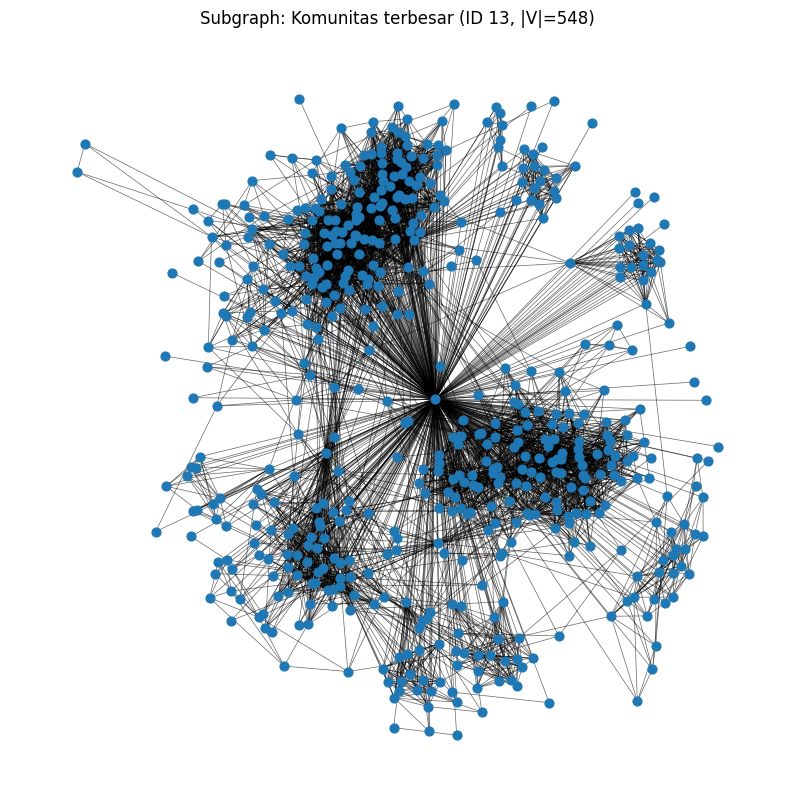

In [ ]:
plt.figure(figsize=(10, 10))
pos_sub = nx.spring_layout(G_largest, seed=42)  # layout khusus subgraph
nx.draw_networkx_nodes(G_largest, pos_sub, node_size=40)
nx.draw_networkx_edges(G_largest, pos_sub, width=0.5, alpha=0.6)
plt.title(f"Subgraph: Komunitas terbesar (ID {largest_cid}, |V|={G_largest.number_of_nodes()})")
plt.axis('off')
plt.show()

# **Deteksi komunitas di dalam komunitas terbesar (sub-komunitas)**

In [ ]:
sub_partition = community_louvain.best_partition(G_largest)

# Relabel sub-komunitas jadi 0..k-1 (opsional)
unique_sub_labels = sorted(set(sub_partition.values()))
sub_label_mapping = {old: new for new, old in enumerate(unique_sub_labels)}
sub_part_relabel = {n: sub_label_mapping[c] for n, c in sub_partition.items()}

# Statistik sub-komunitas
from collections import Counter
sub_counts = Counter(sub_part_relabel.values())
sub_summary = pd.DataFrame([
    {'SubKomunitasID': sid, 'Ukuran': size}
    for sid, size in sub_counts.items()
]).sort_values('Ukuran', ascending=False).reset_index(drop=True)

print("\n=== Statistik sub-komunitas dalam komunitas terbesar ===")
print("Jumlah sub-komunitas yang ditemukan :", len(sub_counts))
display(sub_summary)



=== Statistik sub-komunitas dalam komunitas terbesar ===
Jumlah sub-komunitas yang ditemukan : 9


,SubKomunitasID,Ukuran
0,0,133
1,1,118
2,5,84
3,8,64
4,4,52
5,6,42
6,2,22
7,7,19
8,3,14


In [ ]:
sub_members_rows = []
for node, sid in sub_part_relabel.items():
    sub_members_rows.append({'SubKomunitasID': sid, 'Member': node})
sub_members_df = pd.DataFrame(sub_members_rows)
sub_members_df.to_csv('/content/subcommunity_members_largest.csv', index=False)
print("Daftar anggota sub-komunitas disimpan ke /content/subcommunity_members_largest.csv")

Daftar anggota sub-komunitas disimpan ke /content/subcommunity_members_largest.csv


# **Visualisasi sub-komunitas (warna = sub-komunitas)**

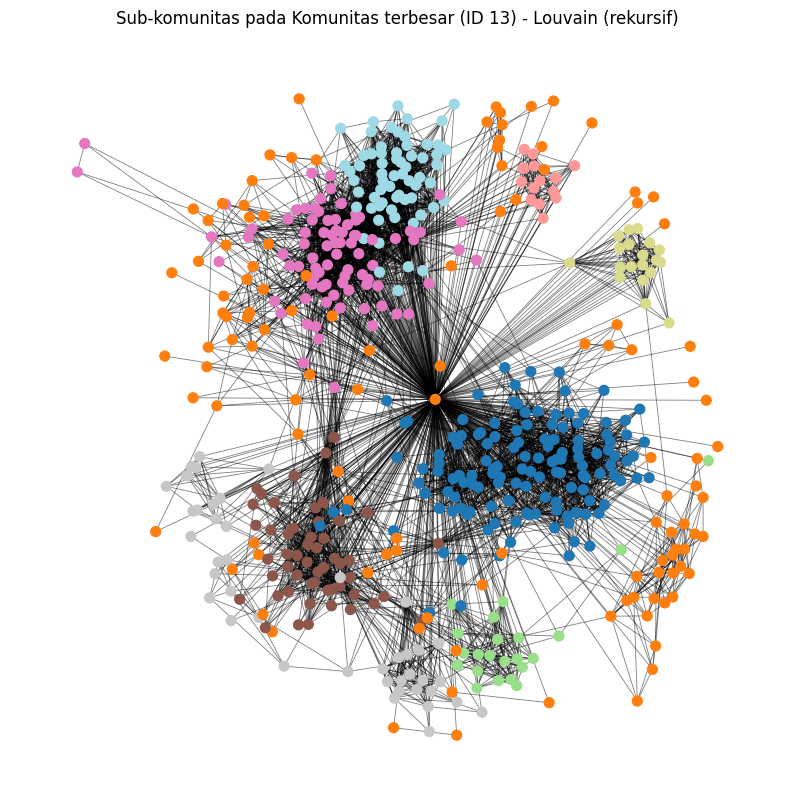

Modularitas partition pada subgraph: 0.622518


In [ ]:
plt.figure(figsize=(10, 10))
# warna berdasarkan sub_part_relabel (nilai 0..k-1)
color_list_sub = [sub_part_relabel[n] for n in G_largest.nodes()]
nx.draw_networkx_nodes(G_largest, pos_sub, node_size=50, node_color=color_list_sub, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_largest, pos_sub, width=0.6, alpha=0.5)
plt.title(f"Sub-komunitas pada Komunitas terbesar (ID {largest_cid}) - Louvain (rekursif)")
plt.axis('off')
plt.show()

# Tampilkan modularitas sub-partition pada subgraph
mod_sub = community_louvain.modularity(sub_partition, G_largest)
print(f"Modularitas partition pada subgraph: {mod_sub:.6f}")